In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
import scanpy as sc
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from scdisentangle.train.tools import get_trainer, set_seed
import scvelo as scv
import phate

import os
import sys
sys.path.append('..')
import local_tools as lt

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
ctype_palette = {
    'Epi_Luminal_1': '#d62728',
    'Epi_Luminal_2Psca': '#264653',
    'Epi_Basal_1': '#f4a261',
    'Epi_Luminal_3Foxi1':'#E69F00' 
}

# Set seed

In [4]:
seed_nb = 42
set_seed(seed_nb)

ic| 'Setting seed to', seed: 42


In [5]:
save_path = f'{FIG_ROOT}/Prostate/cell_transition/ood_transition'
os.makedirs(save_path, exist_ok=True)

# Get Velocity

In [6]:
adata_org = sc.read_h5ad('../../../Datasets/preprocessed_datasets/prostate.h5ad')

sc.pp.normalize_total(adata_org)
sc.pp.log1p(adata_org)

adata_ctrl = adata_org[
    (adata_org.obs['time'] == 'T00') & (adata_org.obs['predType'].isin(['Epi_Luminal_2Psca', 'Epi_Luminal_1']))].copy()

In [7]:
phate_operator = phate.PHATE()
X_phate = phate_operator.fit_transform(adata_ctrl.X)

Calculating PHATE...
  Running PHATE on 3308 observations and 5027 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.98 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.77 seconds.
    Calculating affinities...
    Calculated affinities in 0.06 seconds.
  Calculated graph and diffusion operator in 1.82 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.30 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.07 seconds.
  Calculated landmark operator in 1.83 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 0.87 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.27 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.30 seconds.
Calculated PHATE in 7.08 seconds.


In [8]:
adata_current_cast = sc.read_h5ad('../predictions/T02_Cast_Day7.h5ad')
adata_future_cast = sc.read_h5ad('../predictions/T04_Cast_Day28.h5ad')

adata_velocity_cast = adata_ctrl.copy()
adata_velocity_cast.layers['spliced'] = adata_current_cast.X.copy()
adata_velocity_cast.layers['unspliced'] = adata_future_cast.X.copy()
adata_velocity_cast.layers['velocity'] = adata_velocity_cast.layers['unspliced'] - adata_velocity_cast.layers['spliced']

In [9]:
adata_current_regen = sc.read_h5ad('../predictions/T04_Cast_Day28.h5ad')
adata_future_regen = sc.read_h5ad('../predictions/T05_Regen_Day1.h5ad')

adata_velocity_regen = adata_ctrl.copy()
adata_velocity_regen.layers['spliced'] = adata_current_regen.X.copy()
adata_velocity_regen.layers['unspliced'] = adata_future_regen.X.copy()
adata_velocity_regen.layers['velocity'] = adata_velocity_regen.layers['unspliced'] - adata_velocity_regen.layers['spliced']

# Compute neighbors

In [10]:
scv.pp.neighbors(adata_velocity_cast)
scv.pp.neighbors(adata_velocity_regen)

computing neighbors


2026-02-22 05:54:54.230705: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 05:54:54.245050: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 05:54:54.245068: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 05:54:54.255313: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 05:54:54.854878: W tensorflow/compiler/tf

    finished (0:00:06) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


/tmp/ipykernel_3558529/398573290.py:2: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  scv.pp.neighbors(adata_velocity_regen)
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute PCA with Scanpy first.
  _set_pca(adata=adata, n_pcs=n_pcs, use_highly_variable=use_highly_variable)


computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)


# Project velocities

In [11]:
adata_velocity_cast.obs['clusters'] = adata_velocity_cast.obs['predType']
adata_velocity_regen.obs['clusters'] = adata_velocity_regen.obs['predType']

In [12]:
scv.tl.velocity_graph(adata_velocity_cast)
scv.tl.velocity_graph(adata_velocity_regen)

computing velocity graph (using 1/64 cores)


  0%|          | 0/3308 [00:00<?, ?cells/s]

    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity graph (using 1/64 cores)


  0%|          | 0/3308 [00:00<?, ?cells/s]

    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Get phate embeddings

In [13]:
import phate

In [14]:
adata_velocity_cast.obsm['X_phate'] = X_phate
adata_velocity_regen.obsm['X_phate'] = X_phate

# Streamline plot

In [15]:
# During Castration

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_phate', embedded velocity vectors (adata.obsm)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: 

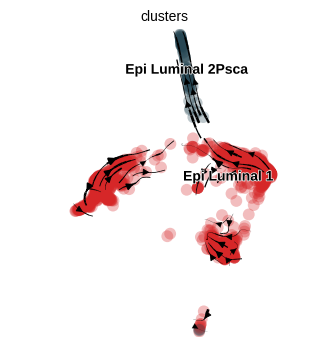

In [16]:
fig, ax = plt.subplots(figsize=(4, 4))
try:
    adata_velocity_cast.uns.pop("predType_colors", None)
except:
    pass
    
scv.pl.velocity_embedding_stream(
    adata_velocity_cast, 
    basis='X_phate',
    show=False,
    ax=ax,
    palette=ctype_palette,
    density=1.5
)
ax.set_aspect('equal')
ax.set_box_aspect(1)

for coll in ax.collections:
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/stream_c7_c28_phate.png', dpi=600)
plt.savefig(f'{save_path}/stream_c7_c28_phate.svg', dpi=600)

In [17]:
# Right after androgen restoration

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_phate', embedded velocity vectors (adata.obsm)


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:65: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return cat(data)  # if data is categorical/array
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scvelo/plotting/utils.py:68: 

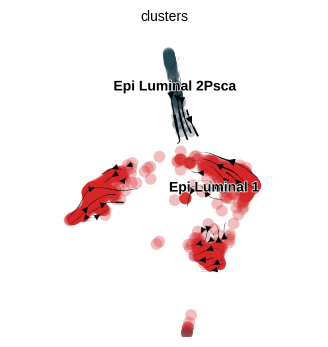

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
try:
    adata_velocity.uns.pop("predType_colors", None)
except:
    pass
    
scv.pl.velocity_embedding_stream(
    adata_velocity_regen, 
    basis='X_phate',
    show=False,
    ax=ax,
    palette=ctype_palette,
    density=1.5,
)
ax.set_aspect('equal')
ax.set_box_aspect(1)

for coll in ax.collections:
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/stream_c28_r1_phate.png', dpi=600)
plt.savefig(f'{save_path}/stream_c28_r1_phate.svg', dpi=600)